In [72]:
import pickle
import random
import warnings
import matplotlib.pyplot as plt
from matplotlib import rcParams
from cmcrameri import cm
import seaborn as sns
from pandas import DataFrame
from numpy import arange, array, isnan
import statsmodels.api as sm
from IPython.display import Markdown, display

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

fs = 12
rcParams['font.family'] = [
    'Noto Sans',
    'Noto Sans Arabic',
    'Noto Sans Tifinagh',
    'Noto Sans CJK JP',
    'Noto Sans Devanagari'
]
sns.set_style('whitegrid')

# Settings

In [3]:
dir_fit = '../output/gev_analysis/pooled/2026-02-06/fit results.pkl'

In [92]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [4]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = random.choice(arange(0, 9579))
end_location = start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 4549–4559


# Load Fit Results

In [5]:
with open(dir_fit, 'rb') as file:
    data = pickle.load(file)

In [6]:
if start_location is not None or end_location is not None: 
    data_cropped = ut.select_allowed_locations(
        dic_data_per_location=data, 
        start_loc=start_location, end_loc=end_location
        )
    print(f'Processing locations {start_location} to {end_location} ({len(data)} total)')

else:
    print(f'Processing all {len(data)} locations')


Processing locations 4549 to 4559 (9589 total)


# Data Processing...

In [11]:
site_ex = random.choice(list(data_cropped.keys()))
print(f'using siteID {site_ex} for inspection')

using siteID 4552 for inspection


In [12]:
data_cropped[site_ex].keys()

dict_keys(['gev_stationary', 'gev_nonstationary'])

In [107]:
df_non_stationary = data_cropped[site_ex]['gev_nonstationary']
df_non_stationary

{'mu0': np.float64(0.896980413609628),
 'mu1': np.float64(-0.007971408766466685),
 'sigma': np.float64(0.17695616076756132),
 'xi': np.float64(-0.2262322446214024),
 'trend_in': 'location',
 'n_obs': 4355,
 'log_likelihood': np.float64(1257.6334372766069),
 'aic': np.float64(-2507.2668745532137),
 'bic': np.float64(-2481.7505549960674),
 'years_mean': np.float64(1993.9249138920782),
 'years_std': np.float64(16.525264704610738),
 'CI': {'mu_pred': array([0.91286264, 0.91286264, 0.91286264, ..., 0.88150813, 0.88150813,
         0.88150813], shape=(4355,)),
  'mu_lower': array([0.90060813, 0.90060813, 0.90060813, ..., 0.86998496, 0.86998496,
         0.86998496], shape=(4355,)),
  'mu_upper': array([0.92511714, 0.92511714, 0.92511714, ..., 0.8930313 , 0.8930313 ,
         0.8930313 ], shape=(4355,))}}

In [14]:
df_annual_location = data_cropped[site_ex]['gev_stationary']['analysis_per_year']
df_annual_location

,shape,location,scale,n_obs,log_likelihood,aic,bic,dist_type,tail_behavior
1962,-0.698418,0.913739,0.20874,12,4.573587,-3.147173,-1.692453,Weibull (Type III),Light (bounded)
1963,-0.08088,0.869142,0.169105,18,4.285713,-2.571425,0.09969,Weibull (Type III),Light (bounded)
1964,-0.059074,0.853612,0.105224,24,16.733943,-27.467886,-23.933725,Weibull (Type III),Light (bounded)
1965,0.105454,0.931523,0.152579,30,7.059832,-8.119663,-3.916071,Fréchet (Type II),Heavy (polynomial)
1966,-0.115392,0.865963,0.139784,38,16.90186,-27.80372,-22.890962,Weibull (Type III),Light (bounded)
...,...,...,...,...,...,...,...,...,...
2022,-0.213027,0.8649,0.156536,41,15.840339,-25.680678,-20.539962,Weibull (Type III),Light (bounded)
2023,-1.267469,0.4721,0.904752,34,0.022322,5.955356,10.534438,Weibull (Type III),Light (bounded)
2024,-0.377268,0.899925,0.144975,26,14.724783,-23.449566,-19.675277,Weibull (Type III),Light (bounded)
2025,-0.007851,0.84442,0.083245,20,18.237308,-30.474617,-27.48742,Gumbel (Type I),Exponential


In [48]:
x = df_annual_location.index  
y = df_annual_location.location.values * 1000
weights = array(df_annual_location.n_obs.values, dtype=float)

WLS directly incorporates weights (in your case, n_obs) to estimate slope and intercept with their standard errors. So the uncertainty comes from the regression model, not a delta approximation.

In [55]:
wls_model = sm.WLS(y, sm.add_constant(x), weights=weights)
results = wls_model.fit()

In [82]:
conf_int = results.conf_int(alpha=0.05)
print("95% CI for intercept and slope:\n", conf_int)

95% CI for intercept and slope:
 [[-1.34927390e+03  4.32703456e+03]
 [-1.73178352e+00  1.11485578e+00]]


continue - plot non-stationary regression

In [110]:
df_non_stationary

{'mu0': np.float64(0.896980413609628),
 'mu1': np.float64(-0.007971408766466685),
 'sigma': np.float64(0.17695616076756132),
 'xi': np.float64(-0.2262322446214024),
 'trend_in': 'location',
 'n_obs': 4355,
 'log_likelihood': np.float64(1257.6334372766069),
 'aic': np.float64(-2507.2668745532137),
 'bic': np.float64(-2481.7505549960674),
 'years_mean': np.float64(1993.9249138920782),
 'years_std': np.float64(16.525264704610738),
 'CI': {'mu_pred': array([0.91286264, 0.91286264, 0.91286264, ..., 0.88150813, 0.88150813,
         0.88150813], shape=(4355,)),
  'mu_lower': array([0.90060813, 0.90060813, 0.90060813, ..., 0.86998496, 0.86998496,
         0.86998496], shape=(4355,)),
  'mu_upper': array([0.92511714, 0.92511714, 0.92511714, ..., 0.8930313 , 0.8930313 ,
         0.8930313 ], shape=(4355,))}}

In [109]:
df_non_stationary['CI']['mu_pred']

array([0.91286264, 0.91286264, 0.91286264, ..., 0.88150813, 0.88150813,
       0.88150813], shape=(4355,))

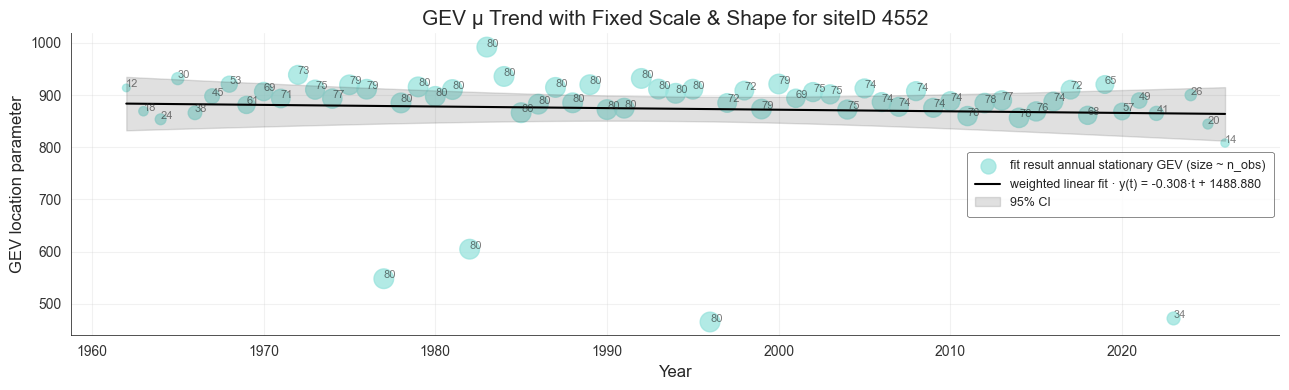

In [106]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(
        x, y, 
        s=weights*2.5, marker='o', color=markers_color, alpha=0.75, 
        label='fit result annual stationary GEV (size ~ n_obs)'
        )
for idx, row in df_annual_location.iterrows():
        ax.text(idx, row.location*1001, f"{row.n_obs}", fontsize=8, alpha=0.6)

intercept, slope = results.params
plt.plot(
        x, results.predict(sm.add_constant(x)), 
        color='k', label=f'weighted linear fit · y(t) = {slope:.3f}·t + {intercept:.3f}'
        )
pred = results.get_prediction(sm.add_constant(x))
ci = pred.conf_int()
ci = array(ci, dtype=float) 
plt.fill_between(x, ci[:, 0], ci[:, 1], color=colors_reg[0], alpha=0.15, label='95% CI')



# ----------------------------------------------------------------------------
# layout
leg = ax.legend(loc=0, edgecolor=axes_color, borderpad=.65, fontsize=fs*0.75)
leg.get_frame().set_linewidth(.5)

for spine in ax.spines.values():
        spine.set_visible(False)

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)

ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.grid(True, alpha=0.3, color='lightgrey')
ax.set_title(
f'GEV μ Trend with Fixed Scale & Shape for siteID {site_ex}', 
fontsize=fs*1.25
)
ax.set_xlabel('Year', fontsize=fs)
ax.set_ylabel('GEV location parameter', fontsize=fs)
plt.tight_layout()
